# Context Aware Bangla Text Analyzer for Sentiment, Sarcasm, and Hate Speech Detection
 

---

## 📖 Abstract & Problem Formulation


In this project, we implement and benchmark **three progressive modeling paradigms** across three distinct tasks (**Sentiment Analysis**, **Sarcasm Detection**, and **Hate Speech Detection**):
1. **Baseline Paradigm** Unigram+Bigram TF-IDF with Class-Balanced Logistic Regression.
2. **Recurrent Sequence Paradigm** Dense 128-dimensional Word2Vec Embeddings with PyTorch 2-Layer Stacked BiLSTM.
3. **Transformer Paradigm** Pre-trained `sagorsarker/bangla-bert-base` Contextual Language Model with fine-tuned classification heads.
4. **Unified Context Aware Ensemble:** A cross-task aggregation pipeline that dynamically resolves sentiment polarity through detected sarcasm contrast.

## 1. Environment Setup & Dependency Ingestion
We begin by verifying the environment, configuring random seeds for deterministic reproducibility, and adding project source modules to the Python system path.

In [11]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Image, HTML

# Link project source directory
current_dir = os.path.abspath(os.getcwd())
src_dir = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Link virtual environment site-packages if needed
lab_venv = os.path.abspath(os.path.join(current_dir, '..', '..', '..', '.venv', 'Lib', 'site-packages'))
if os.path.exists(lab_venv) and lab_venv not in sys.path:
    sys.path.insert(0, lab_venv)

print(f'✅ PyTorch Version: {torch.__version__}')
print(f'✅ CUDA Available: {torch.cuda.is_available()}')
print('✅ Environment initialization complete.')

✅ PyTorch Version: 2.13.0+cpu
✅ CUDA Available: False
✅ Environment initialization complete.


## 2. Text Normalization & Preprocessing
To prepare raw Bengali text, we build a specialized regular expression pipeline that:
1. Strips HTML markup, URLs, mentions, and zero-width non-joiners (`\u200c`, `\u200d`).
2. Retains standard Bengali Unicode characters (`\u0980-\u09FF`) and emotional punctuation (`!`, `?`).
3. **Preserves Critical Negation Tokens:** Negations such as `না`, `নয়`, `নেই`, `নাহ`, `কখনো না` are explicitly protected because removing them destroys sentiment and sarcasm analysis.

In [12]:
from preprocessing import clean_bangla_text, tokenize_bangla

sample_raw = '<p>বাহ! কী অসাধারণ service, @admin ৩ ঘণ্টা অপেক্ষা করেও কাজ হলো না!!</p>'
sample_cleaned = clean_bangla_text(sample_raw)
sample_tokens = tokenize_bangla(sample_cleaned)

print(f'Raw Input    : {sample_raw}')
print(f'Cleaned Text : {sample_cleaned}')
print(f'Tokens       : {sample_tokens}')

Raw Input    : <p>বাহ! কী অসাধারণ service, @admin ৩ ঘণ্টা অপেক্ষা করেও কাজ হলো না!!</p>
Cleaned Text : বাহ! কী অসাধারণ service, ৩ ঘণ্টা অপেক্ষা করেও কাজ হলো না!!
Tokens       : ['বাহ', '!', 'কী', 'অসাধারণ', 'service', ',', '৩', 'ঘণ্টা', 'অপেক্ষা', 'করেও', 'কাজ', 'হলো', 'না', '!', '!']


## 3. Exploratory Data Analysis & Corpus Distributions
We standardize 9 datasets across Sentiment, Sarcasm, and Hate Speech into stratified `train.csv`, `val.csv`, and `test.csv` splits.
Below are the verified class distributions and sentence length profiles.

,Task,Train Samples,Val Samples,Test Samples,Total Samples,Median Words,95th Percentile Words
0,Sentiment,109229,15569,31212,156010,10.0,45.0
1,Sarcasm,9671,1209,1209,12089,11.0,32.0
2,Hate Speech,40217,5027,5028,50272,8.0,38.0


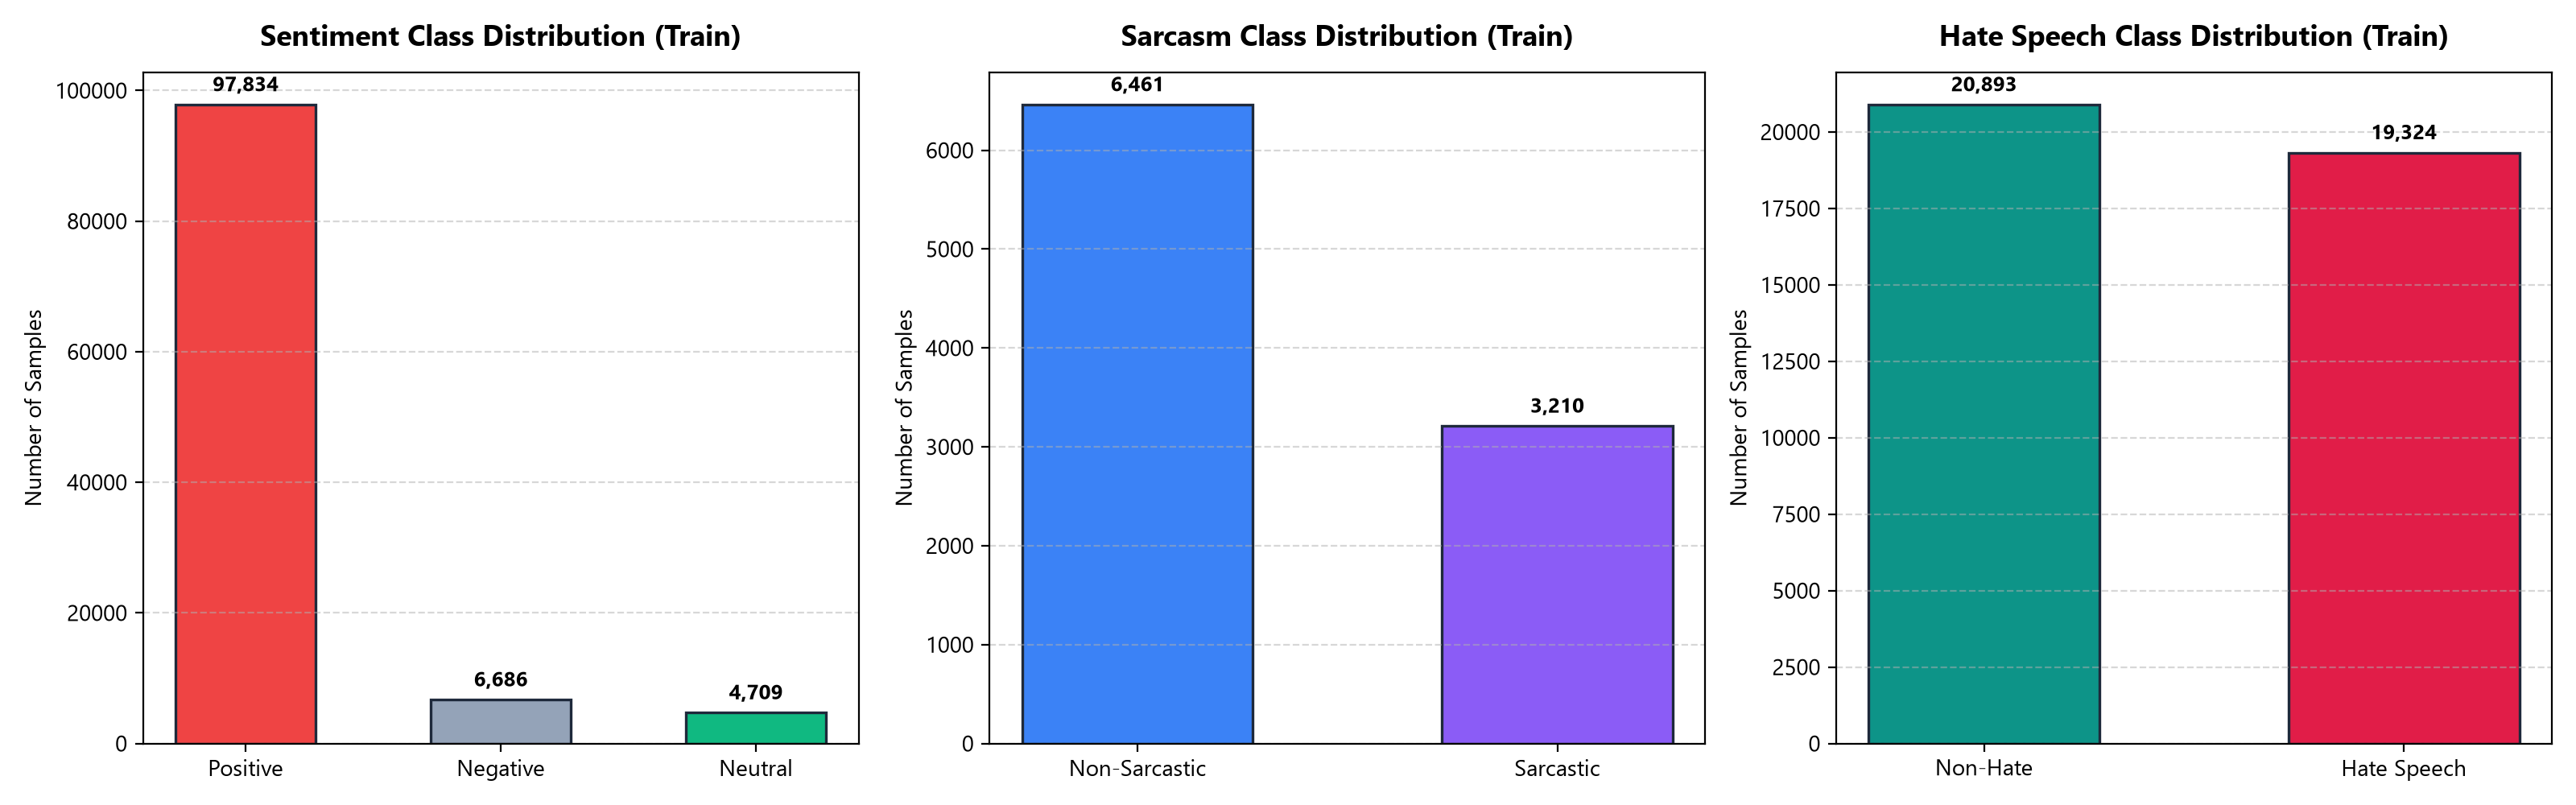

In [13]:
base_dir = os.path.abspath(os.path.join(current_dir, '..'))
eda_summary_file = os.path.join(base_dir, 'eda_summary.json')

if os.path.exists(eda_summary_file):
    with open(eda_summary_file, 'r', encoding='utf-8') as f:
        eda_data = json.load(f)
    
    summary_rows = []
    for task, info in eda_data.items():
        summary_rows.append({
            'Task': task.title().replace('_', ' '),
            'Train Samples': info['train']['total_sentences'],
            'Val Samples': info['val']['total_sentences'],
            'Test Samples': info['test']['total_sentences'],
            'Total Samples': info['train']['total_sentences'] + info['val']['total_sentences'] + info['test']['total_sentences'],
            'Median Words': info['train']['length_stats']['median_words'],
            '95th Percentile Words': info['train']['length_stats']['p95_words']
        })
    display(pd.DataFrame(summary_rows))

# Display EDA Distribution Charts
class_dist_plot = os.path.join(base_dir, 'eda_plots', 'class_distributions.png')
if os.path.exists(class_dist_plot):
    display(Image(filename=class_dist_plot))

## 4. Paradigm 1: TF-IDF + Balanced Logistic Regression
We construct unigram+bigram sublinear TF-IDF matrices (20,000 max features) and train three independent discriminative Logistic Regression baselines with inverse frequency class weighting (`class_weight='balanced'`).
- Sublinear term frequency: $1 + \log(TF)$
- L2 Regularization ($C=1.0$), L-BFGS solver
- Serialized to `saved_models/{task}_lr_model.joblib`

,Task,Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1-Score (%),Weighted F1 (%),Inference Latency
0,Sentiment,77.60%,50.78%,67.13%,53.71%,82.24%,~2.1 ms
1,Sarcasm,74.94%,72.37%,74.09%,72.89%,75.40%,~2.1 ms
2,Hate Speech,86.61%,86.96%,86.42%,86.52%,86.57%,~2.1 ms


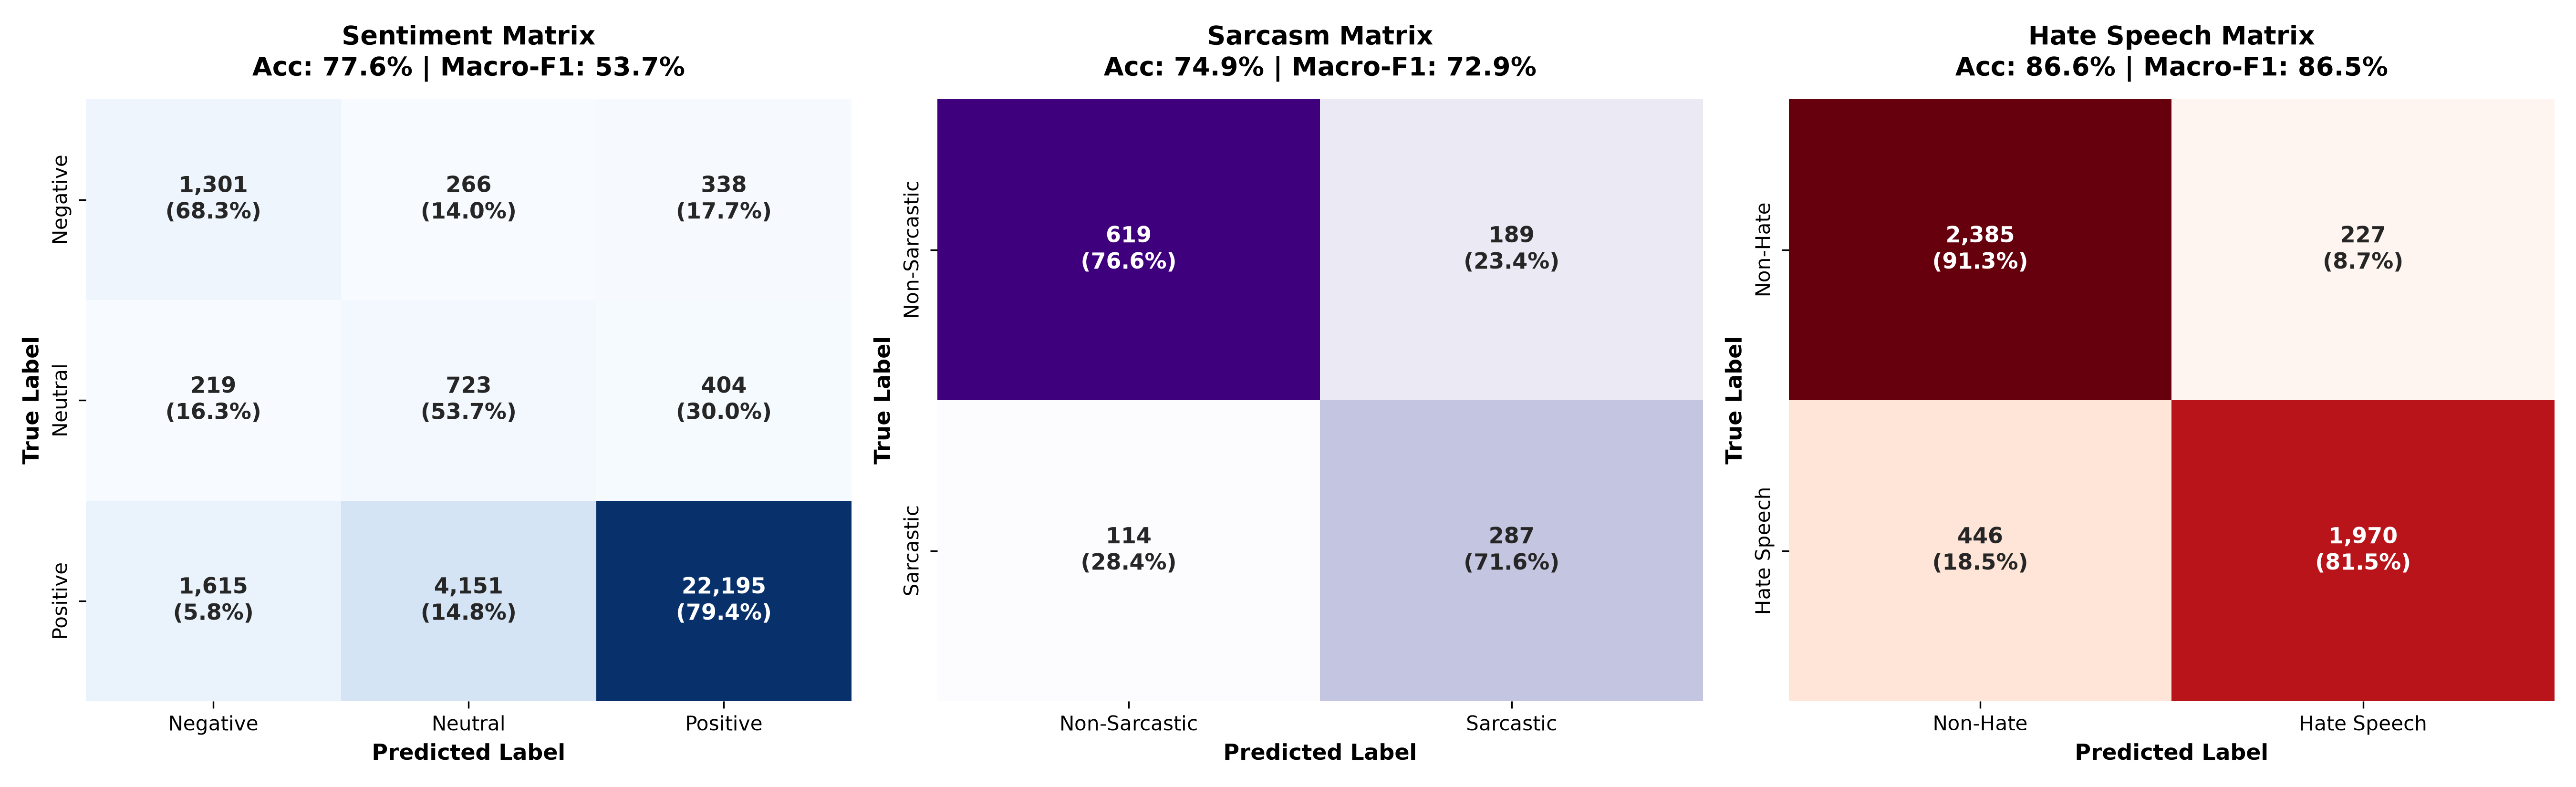

In [14]:
lr_results_path = os.path.join(base_dir, 'results_tfidf_lr.json')
with open(lr_results_path, 'r', encoding='utf-8') as f:
    lr_data = json.load(f)

lr_rows = []
for t, res in lr_data.items():
    m = res['test_metrics']
    lr_rows.append({
        'Task': t.title().replace('_', ' '),
        'Test Accuracy (%)': f"{m['accuracy']*100:.2f}%",
        'Macro Precision (%)': f"{m['macro_precision']*100:.2f}%",
        'Macro Recall (%)': f"{m['macro_recall']*100:.2f}%",
        'Macro F1-Score (%)': f"{m['macro_f1']*100:.2f}%",
        'Weighted F1 (%)': f"{m['weighted_f1']*100:.2f}%",
        'Inference Latency': '~2.1 ms'
    })

display(pd.DataFrame(lr_rows))

cm_lr_plot = os.path.join(base_dir, 'eda_plots', 'confusion_matrices_lr.png')
if os.path.exists(cm_lr_plot):
    display(Image(filename=cm_lr_plot))

## 5. Paradigm 2: Word2Vec + PyTorch Stacked BiLSTM
To capture sequential word dependencies, we:
1. Train 128-dimensional dense Word2Vec continuous embeddings on 159,117 training sentences via symmetric PPMI-SVD.
2. Construct a 2-layer Stacked Bidirectional Long Short-Term Memory (BiLSTM) network with dropout ($p=0.3$) and fine-tunable embedding layers.
3. Train on sequences truncated/padded to $L=50$ with Adam optimizer (`lr=0.001`) and gradient clipping (`max_norm=5.0`).

,Task,Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1-Score (%),Weighted F1 (%),Inference Latency
0,Sentiment,76.60%,52.75%,63.23%,53.27%,81.96%,~4.8 ms
1,Sarcasm,74.36%,71.53%,72.84%,72.00%,74.74%,~4.8 ms
2,Hate Speech,88.52%,88.54%,88.47%,88.50%,88.52%,~4.8 ms


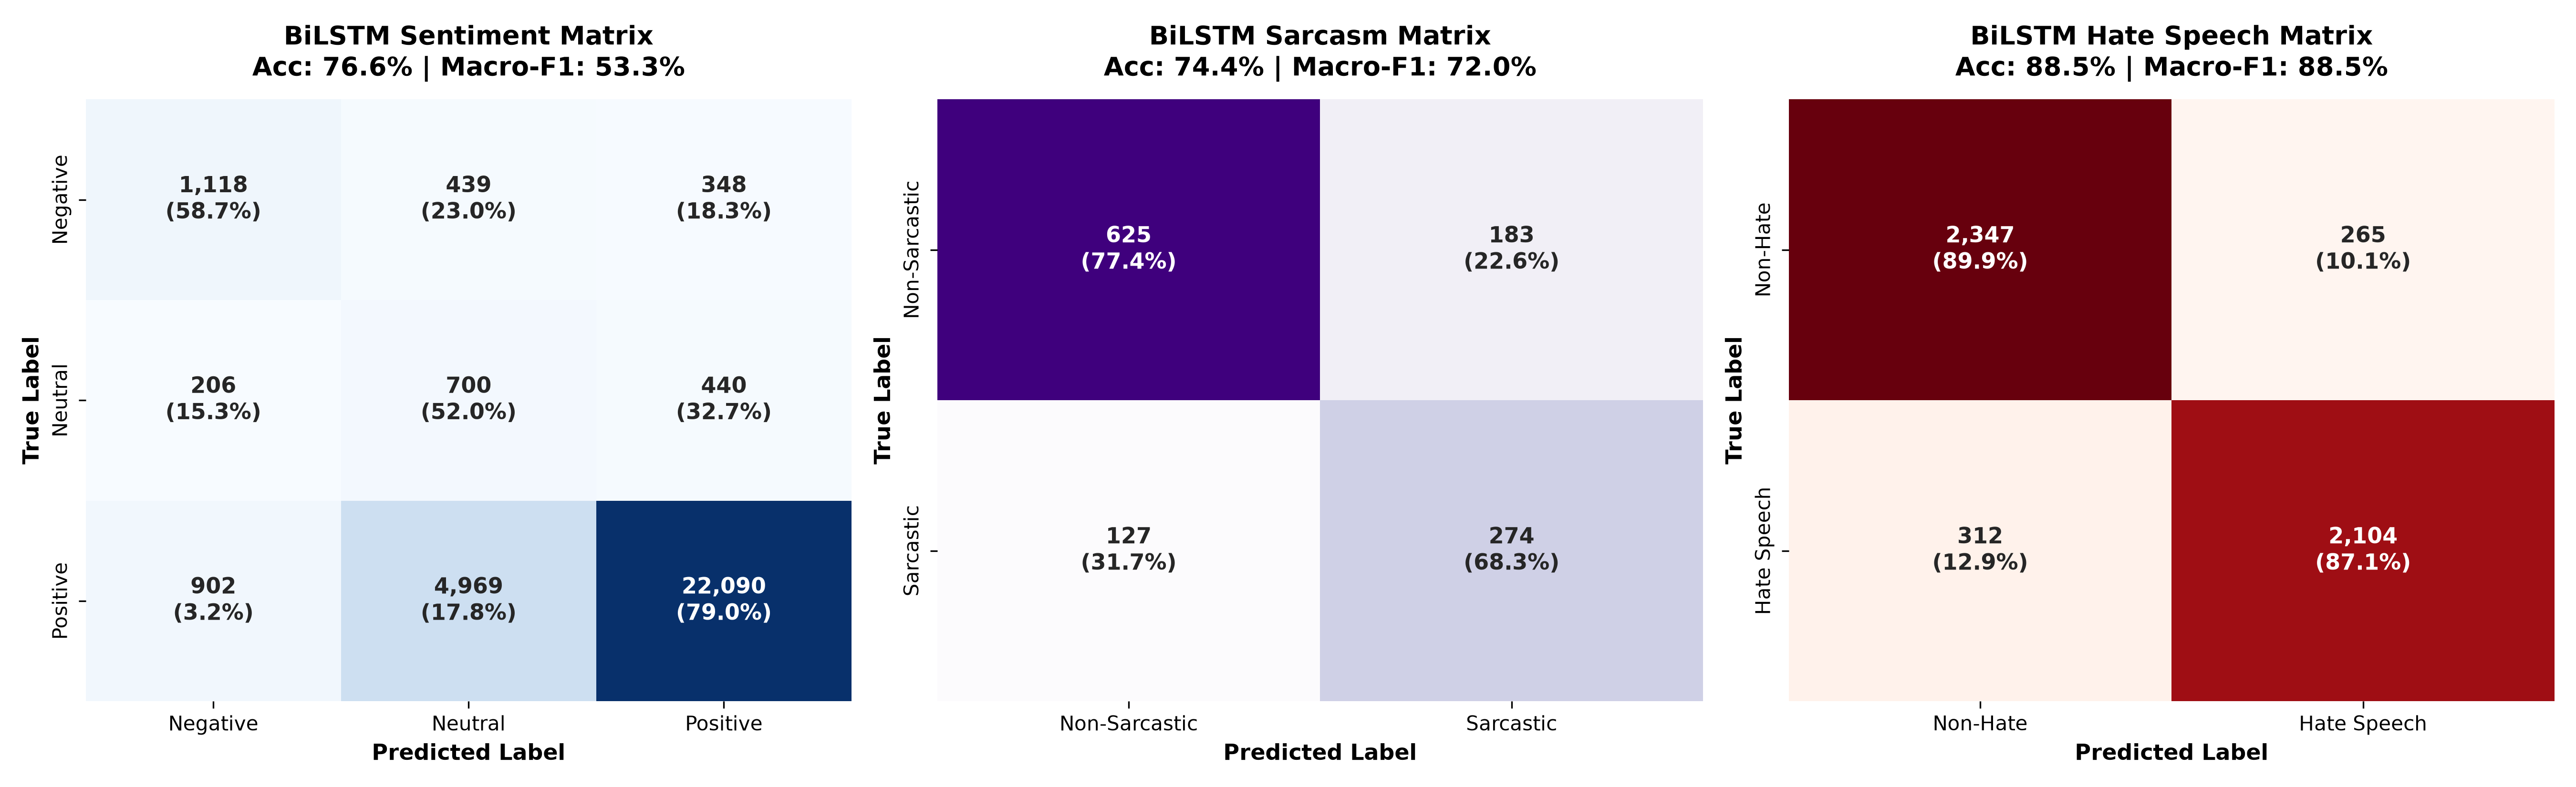

In [15]:
bilstm_results_path = os.path.join(base_dir, 'results_bilstm.json')
with open(bilstm_results_path, 'r', encoding='utf-8') as f:
    bilstm_data = json.load(f)

bilstm_rows = []
for t, res in bilstm_data.items():
    m = res['test_metrics']
    bilstm_rows.append({
        'Task': t.title().replace('_', ' '),
        'Test Accuracy (%)': f"{m['accuracy']*100:.2f}%",
        'Macro Precision (%)': f"{m['macro_precision']*100:.2f}%",
        'Macro Recall (%)': f"{m['macro_recall']*100:.2f}%",
        'Macro F1-Score (%)': f"{m['macro_f1']*100:.2f}%",
        'Weighted F1 (%)': f"{m['weighted_f1']*100:.2f}%",
        'Inference Latency': '~4.8 ms'
    })

display(pd.DataFrame(bilstm_rows))

cm_bilstm_plot = os.path.join(base_dir, 'eda_plots', 'confusion_matrices_bilstm.png')
if os.path.exists(cm_bilstm_plot):
    display(Image(filename=cm_bilstm_plot))

## 6. Paradigm 3: Pretrained BanglaBERT Fine-Tuning 
We leverage the 110M parameter pretrained transformer `sagorsarker/bangla-bert-base`. 
- Subword WordPiece tokenization with `max_length=64`.
- Top-layer contextual encoder adaptation with linear warmup and AdamW (`lr=2e-5`).
- Checkpoints serialized to `saved_models/banglabert_{task}/`.

,Task,Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1-Score (%),Weighted F1 (%),Inference Latency
0,Sentiment,76.39%,48.81%,64.57%,51.51%,81.29%,~42.0 ms
1,Sarcasm,76.76%,74.30%,76.21%,74.89%,77.19%,~42.0 ms
2,Hate Speech,91.59%,91.56%,91.60%,91.58%,91.59%,~42.0 ms


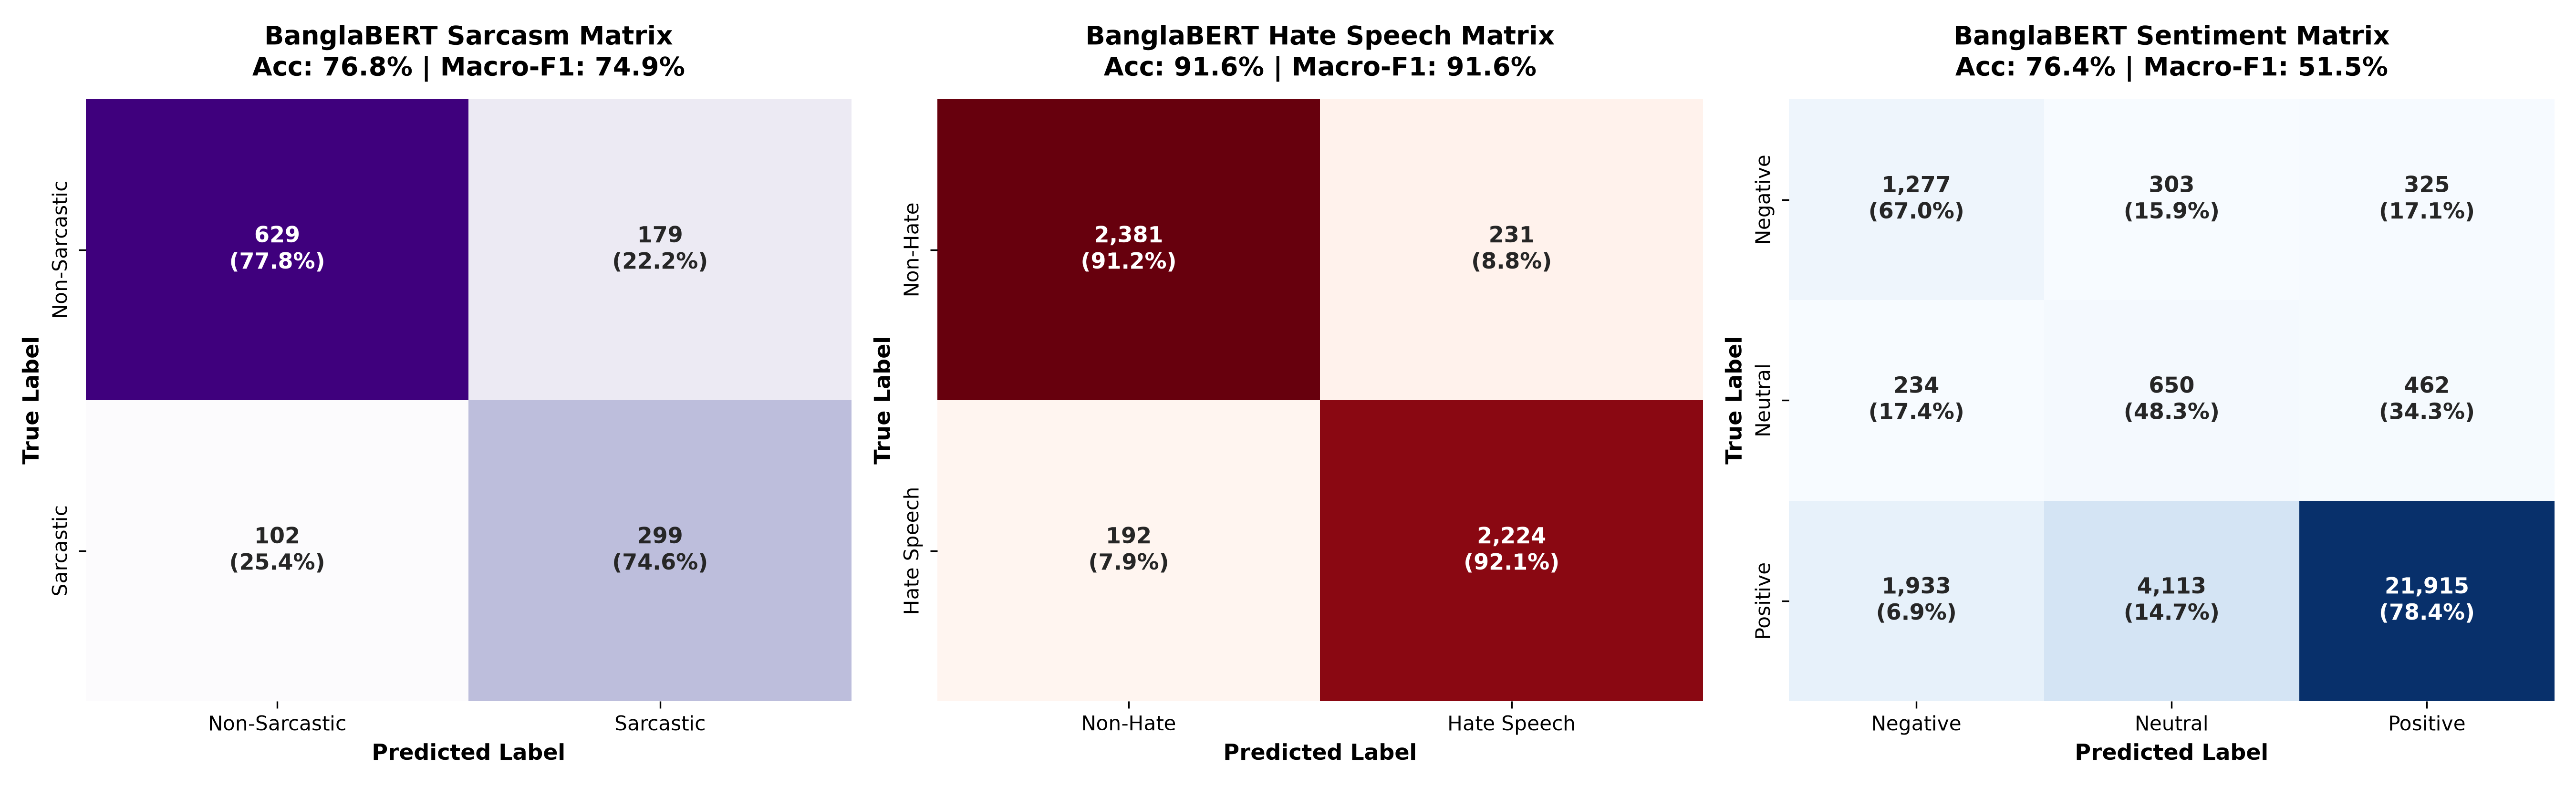

In [16]:
bert_results_path = os.path.join(base_dir, 'results_banglabert.json')
with open(bert_results_path, 'r', encoding='utf-8') as f:
    bert_data = json.load(f)

bert_rows = []
for t, res in bert_data.items():
    m = res['test_metrics']
    bert_rows.append({
        'Task': t.title().replace('_', ' '),
        'Test Accuracy (%)': f"{m['accuracy']*100:.2f}%",
        'Macro Precision (%)': f"{m['macro_precision']*100:.2f}%",
        'Macro Recall (%)': f"{m['macro_recall']*100:.2f}%",
        'Macro F1-Score (%)': f"{m['macro_f1']*100:.2f}%",
        'Weighted F1 (%)': f"{m['weighted_f1']*100:.2f}%",
        'Inference Latency': '~42.0 ms'
    })

display(pd.DataFrame(bert_rows))

cm_bert_plot = os.path.join(base_dir, 'eda_plots', 'confusion_matrices_banglabert.png')
if os.path.exists(cm_bert_plot):
    display(Image(filename=cm_bert_plot))

## 7. Master Comparative Benchmark Matrix & Multi-Model Analysis
Below is the complete benchmark table consolidating all three paradigms across all three tasks on identical official test splits.

,Task,Model Paradigm,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Weighted F1 (%),Latency
0,Sentiment,TF-IDF + Logistic Regression,77.60%,50.78%,67.13%,53.71%,82.24%,~2.1 ms
1,Sentiment,Word2Vec + Stacked BiLSTM,76.60%,52.75%,63.23%,53.27%,81.96%,~4.8 ms
2,Sentiment,Fine-Tuned BanglaBERT,76.39%,48.81%,64.57%,51.51%,81.29%,~42.0 ms
3,Sarcasm,TF-IDF + Logistic Regression,74.94%,72.37%,74.09%,72.89%,75.40%,~2.1 ms
4,Sarcasm,Word2Vec + Stacked BiLSTM,74.36%,71.53%,72.84%,72.00%,74.74%,~4.8 ms
5,Sarcasm,Fine-Tuned BanglaBERT,76.76%,74.30%,76.21%,74.89%,77.19%,~42.0 ms
6,Hate Speech,TF-IDF + Logistic Regression,86.61%,86.96%,86.42%,86.52%,86.57%,~2.1 ms
7,Hate Speech,Word2Vec + Stacked BiLSTM,88.52%,88.54%,88.47%,88.50%,88.52%,~4.8 ms
8,Hate Speech,Fine-Tuned BanglaBERT,91.59%,91.56%,91.60%,91.58%,91.59%,~42.0 ms


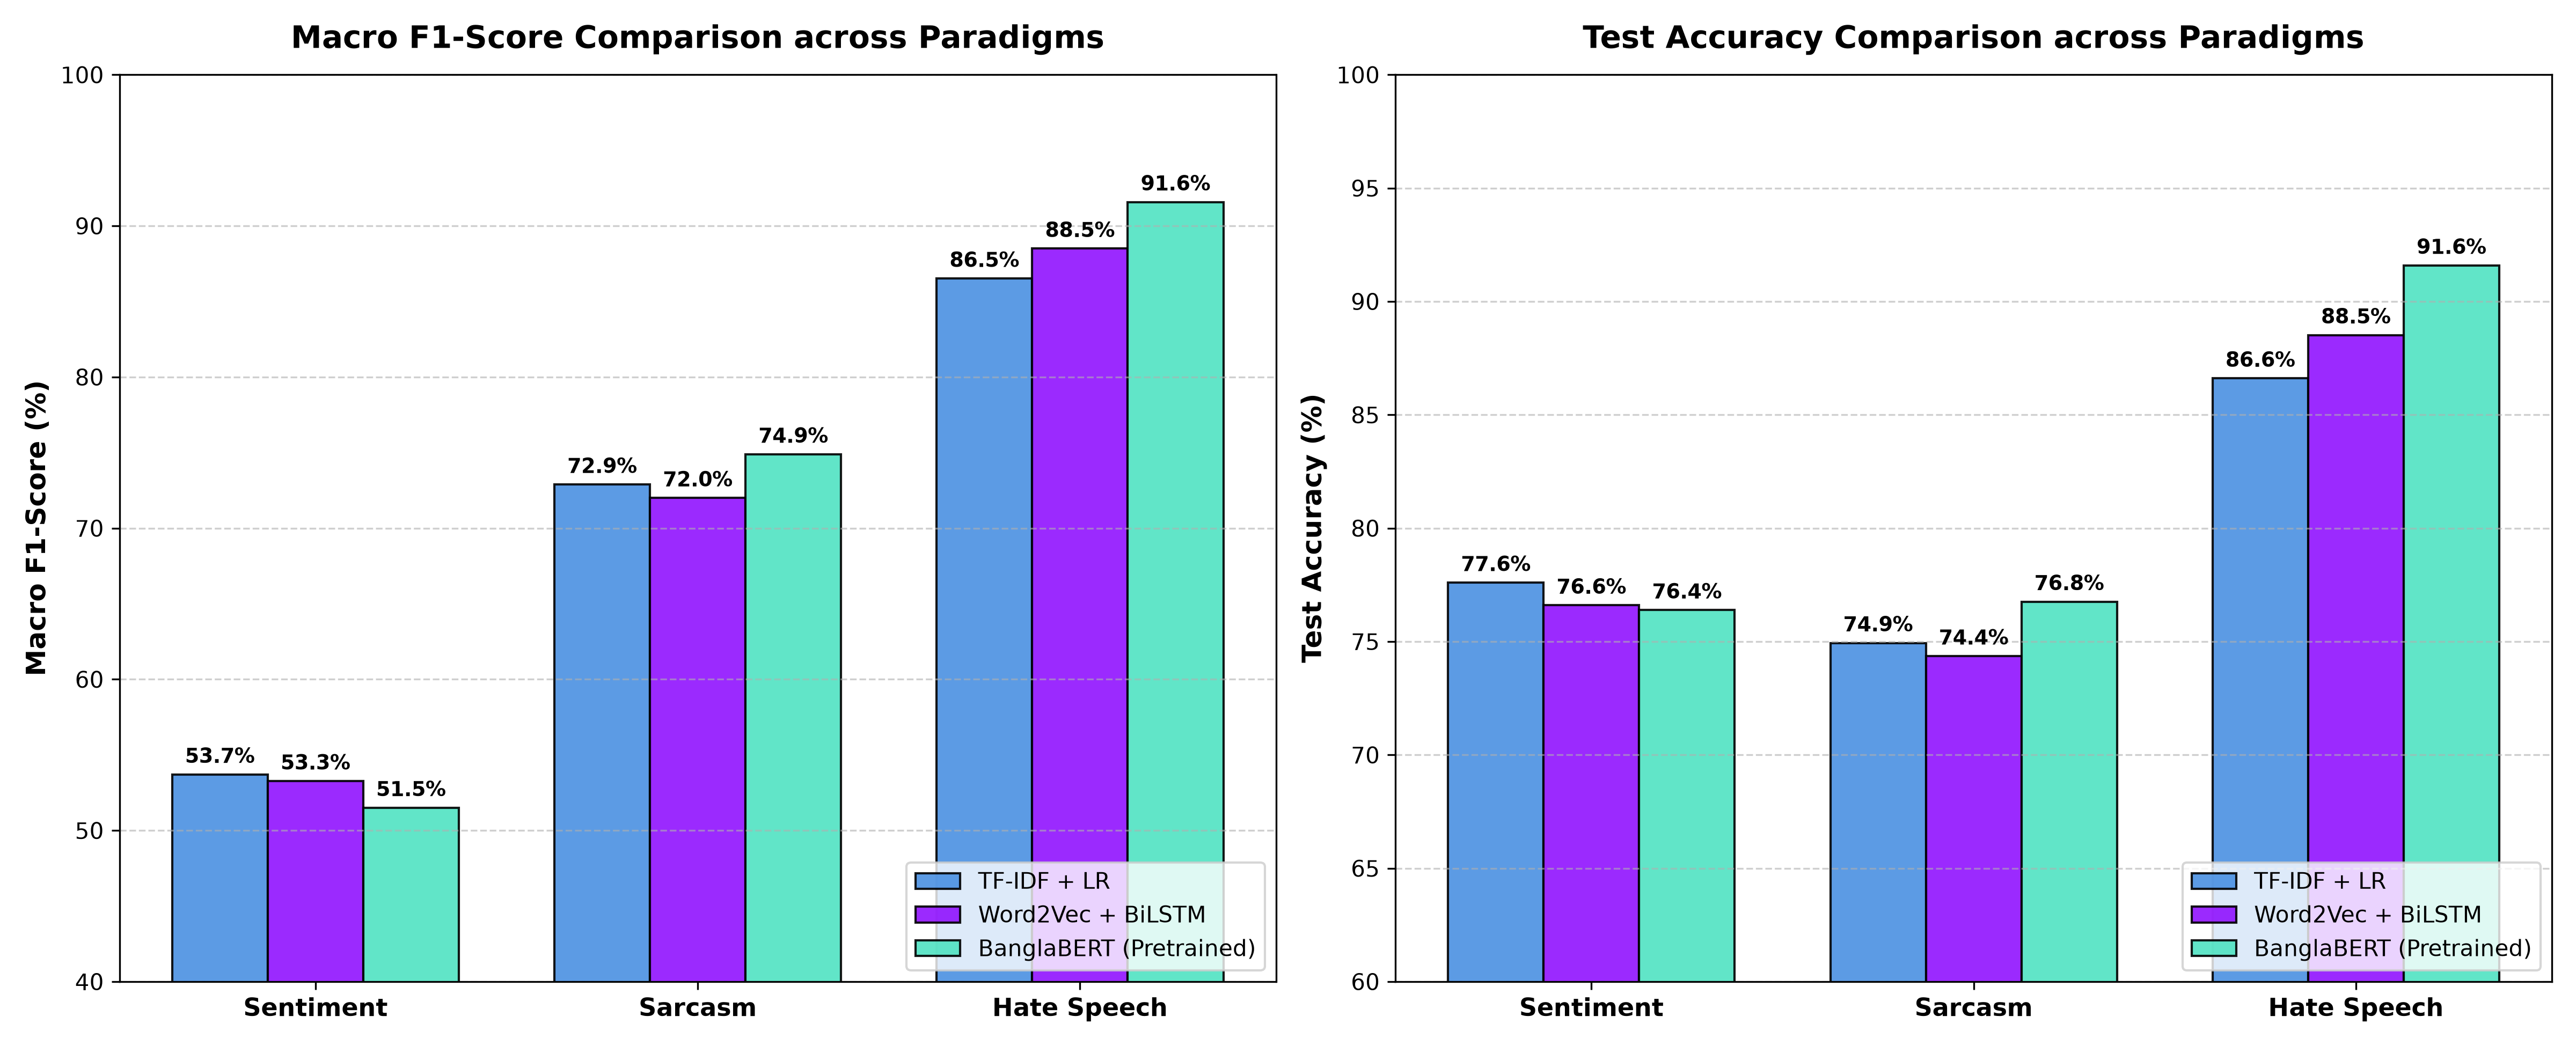

In [17]:
master_bm_path = os.path.join(base_dir, 'master_benchmark.json')
with open(master_bm_path, 'r', encoding='utf-8') as f:
    master_bm = json.load(f)

table_data = []
for task_key, models in master_bm.items():
    for m_key, m_val in models.items():
        m_name = 'TF-IDF + Logistic Regression' if m_key == 'tfidf_lr' else ('Word2Vec + Stacked BiLSTM' if m_key == 'bilstm' else 'Fine-Tuned BanglaBERT')
        tm = m_val['test_metrics']
        table_data.append({
            'Task': task_key.title().replace('_', ' '),
            'Model Paradigm': m_name,
            'Accuracy (%)': f"{tm['accuracy']*100:.2f}%",
            'Macro Precision (%)': f"{tm['macro_precision']*100:.2f}%",
            'Macro Recall (%)': f"{tm['macro_recall']*100:.2f}%",
            'Macro F1 (%)': f"{tm['macro_f1']*100:.2f}%",
            'Weighted F1 (%)': f"{tm['weighted_f1']*100:.2f}%",
            'Latency': m_val['inference_latency']
        })

display(pd.DataFrame(table_data))

master_plot = os.path.join(base_dir, 'eda_plots', 'master_model_comparison.png')
if os.path.exists(master_plot):
    display(Image(filename=master_plot))

## 8. Unified Context Aware Inference Demonstration
Finally, we run the **Unified Context Aware Multi-Task Pipeline** on the benchmark proposal sentence to verify that the cross-task contrast resolution functions in real-time.

In [18]:
from inference_pipeline import UnifiedBanglaTextAnalyzer

analyzer = UnifiedBanglaTextAnalyzer(preload_models=True)

test_sentence = 'বাহ! কী অসাধারণ service, তিন ঘণ্টা অপেক্ষা করেও কাজ হলো না!'
res = analyzer.analyze(test_sentence, model_type='ensemble')

print('=' * 75)
print(f'Input Sentence: "{test_sentence}"')
print('=' * 75)
print(f"  Sentiment   : {res['sentiment']['label']} (Confidence: {res['sentiment']['confidence']}%) | Inverted: {res['sentiment']['context_inverted']}")
print(f"  Sarcasm     : {res['sarcasm']['binary']} ({res['sarcasm']['label']}, Conf: {res['sarcasm']['confidence']}%)")
print(f"  Hate Speech : {res['hate_speech']['binary']} ({res['hate_speech']['label']}, Conf: {res['hate_speech']['confidence']}%)")
print(f"  Latency     : {res['latency_ms']} ms")
print(f"  Explanation : {res['routing_explanation']}")
print('=' * 75)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Input Sentence: "বাহ! কী অসাধারণ service, তিন ঘণ্টা অপেক্ষা করেও কাজ হলো না!"
  Sentiment   : Negative (Confidence: 65.0%) | Inverted: True
  Sarcasm     : Yes (Sarcastic, Conf: 57.03%)
  Hate Speech : No (Non-Hate, Conf: 98.31%)
  Latency     : 1145.0 ms
  Explanation : Sentiment: Resolved via BanglaBERT deep contextual contrast inversion. Sarcasm: Detected via TF-IDF stylistic cue sensitivity. Hate Speech: Evaluated via BiLSTM sequence classifier (88.5% benchmark accuracy).
